## **신도시 아파트 가격 예측 (LinearRegression)**

- 과거의 신도시 아파트 거래 데이터를 훈련 세트로 활용하여 **검단호수공원역 파밀리에 엘리프** 아파트의 가격을 시나리오별로 예측 (What-If 분석)

#### **0. 라이브러리 임포트**

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

#### **1. 데이터 불러오기**

In [2]:
# ── 데이터 불러오기 ──
train_folder = r"C:\3_1_DataMining\팀 프로젝트\신도시 데이터\new_city.csv"
test_folder  = r"C:\3_1_DataMining\팀 프로젝트\geomdan_merged.csv"




df_all  = pd.read_csv(train_folder ,     encoding='utf-8-sig')
df_train = df_all[df_all['도시명'].isin(['운정','광교', '판교'])].copy()
df_test = pd.read_csv(test_folder  , encoding='utf-8-sig')

#### **2. 데이터 전처리**

- **2-1. 거래금액 숫자 변환**

In [3]:
# ── 거래금액 전처리 ──
df_train['거래금액(만원)'] = df_train['거래금액(만원)'].str.replace(',', '').astype(int)
df_test['거래금액(만원)'] = df_test['거래금액(만원)'].str.replace(',', '').astype(int)


- **2-2. ㎡당 가격 파생변수 생성**

In [4]:
df_train['m2당가격'] = df_train['거래금액(만원)'] / df_train['전용면적(㎡)']
df_test['m2당가격'] = df_test['거래금액(만원)'] / df_test['전용면적(㎡)']

- **2-3. 발표 후 경과년수 필터링**

In [5]:
# ── 발표후경과년수 3 미만 제거 ──
df_train = df_train[df_train['발표후경과년수'] >= 3]
df_test = df_test[df_test['발표후경과년수'] >= 3]

- **2-4. 훈련 데이터 연도 제한 및 검단 데이터 합산**

In [ ]:
df_geomdan_train = df_test[df_test['계약연도'] <= 2024].copy()
df_test = df_test[df_test['계약연도'] >= 2024].copy()
df_train = pd.concat([df_train, df_geomdan_train], ignore_index=True)

- **2-5. 이상치 제거 (z-score)**

In [7]:
# ── 이상치 제거 ──
df_train = df_train[df_train['전용면적(㎡)'] >= 33]
print(f"이상치 제거 전 데이터 건수: {len(df_train)}")

# 전용면적 33제곱미터 미만 제거 (논문 기준: 거래 빈도 낮고 가격 편차 심함)
df_train = df_train[df_train['전용면적(㎡)'] >= 33]
print(f"전용면적 33㎡ 미만 제거 후: {len(df_train)}")

# 거래금액 z-score 기준 이상치 제거 (|z| > 2인 데이터 제거)
mean = df_train['m2당가격'].mean()
std = df_train['m2당가격'].std()
z_scores = (df_train['m2당가격'] - mean) / std
df_train = df_train[z_scores.abs() <= 2]
print(f"z-score 이상치 제거 후: {len(df_train)}")

print(f"훈련 데이터: {len(df_train)}건")
print(f"테스트 데이터: {len(df_test)}건")

이상치 제거 전 데이터 건수: 64088
전용면적 33㎡ 미만 제거 후: 64088
z-score 이상치 제거 후: 60191
훈련 데이터: 60191건
테스트 데이터: 6106건


#### **3. 입력 변수, 타겟 변수 설정**

In [8]:
# ── 독립변수 / 타겟 설정 ──
features = ['건축년도', '층',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리',
            '단지별_세대수', '도시별_세대수']

df_train = df_train.dropna(subset=features + ['m2당가격'])
df_test = df_test.dropna(subset=features + ['m2당가격'])

train_input = df_train[features]
train_target = df_train['m2당가격']
test_input = df_test[features]
test_target = df_test['m2당가격']

#### **4. 특성 표준화 (StandardScaler)**

In [9]:
# ── 표준화 ──
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#### **5. 선형 회귀 모델 학습**

In [10]:
# ── 선형 회귀 모델 학습 ──
model = LinearRegression()
model.fit(train_scaled, train_target)

y_pred = model.predict(test_scaled)

mae  = mean_absolute_error(test_target, y_pred)
mse  = mean_squared_error(test_target, y_pred)
rmse = np.sqrt(mse)
r2   = model.score(test_scaled, test_target)

print("선형 회귀 모델 학습 완료")
print(f"훈련 세트 R²:          {model.score(train_scaled, train_target):.4f}")
print(f"테스트 세트 R² (검단): {r2:.4f}")
print(f"MAE  : {mae:.2f} 만원/㎡")
print(f"RMSE : {rmse:.2f} 만원/㎡")

선형 회귀 모델 학습 완료
훈련 세트 R²:          0.8198
테스트 세트 R² (검단): 0.7849
MAE  : 76.70 만원/㎡
RMSE : 97.99 만원/㎡


#### **6. What-If 분석 — 검단호수공원역 파밀리에 엘리프 (2027년)**

In [11]:
# 파라곤 기본 특성값
# 검단호수공원역 파라곤 (불로동, 569세대, 84㎡ 단일평형, 2028년 입주)
# ── 파밀리에 엘리프 기본 특성값 ──
엘리프_기본 = {
    '건축년도': 2027,
    '층': 10,
    '지하철호선개수': 2,
    '기차역까지의거리': 15.6213,
    '가장 가까운 지하철역까지의 거리': 1.206,
    '가장 가까운 IC와의 거리': 4.867,
    '발표후경과년수': 21,
    'CPI': 122.6,
    '계약연도': 2027,
    '서울도심거리': 26.5,
    '단지별_세대수': 669,
    '도시별_세대수': 60833
}

#### **7. 시나리오 설정**

- **현재**: 기본 특성값 그대로
- **발표 후 25년**: 경과년수 25년, 계약연도 2031년, CPI 130.0 적용
- **지하철 추가**: 지하철 호선 3개, 인근역까지 0.5km 적용
- **복합 시나리오**: 발표 후 25년 + 지하철 추가 조건 동시 적용

In [12]:
# ── 시나리오 설정 ──
# ── 층수별 × 시나리오별 (84㎡) ──
면적_84 = 84.0
층수_목록 = {'저층 (3층)': 3, '중층 (10층)': 10, '고층 (20층)': 20}

시나리오_목록 = {
    '현재': 엘리프_기본.copy(),
    '발표 후 25년': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 130.0},
    '지하철 추가': {**엘리프_기본, '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
    '복합 시나리오': {**엘리프_기본, '발표후경과년수': 25, '계약연도': 2031, 'CPI': 130.0,
                  '지하철호선개수': 3, '가장 가까운 지하철역까지의 거리': 0.5},
}

#### **8. 층수별 × 시나리오별 예측**

In [13]:
면적 = 84.0
층수_목록 = {'저층 (3층)': 3, '중층 (10층)': 10, '고층 (20층)': 20}

print(f"\n{chr(61)*60}")
print("검단호수공원역 파라곤 층수별 × 시나리오별 예측 (84㎡)")
print(f"{chr(61)*60}")

층수_결과 = {}
for 층이름, 층값 in 층수_목록.items():
    층수_결과[층이름] = []
    for 시나리오명, 값 in 시나리오_목록.items():
        입력값 = dict(값)
        입력값['층'] = 층값
        입력 = pd.DataFrame([입력값])[features]
        입력_scaled = ss.transform(입력)
        예측_m2 = model.predict(입력_scaled)[0]
        예측_금액 = int(예측_m2 * 면적)
        층수_결과[층이름].append(예측_금액)
        print(f"{층이름} | {시나리오명}: {예측_금액:,}만원 ({예측_금액/10000:.1f}억)")


검단호수공원역 파라곤 층수별 × 시나리오별 예측 (84㎡)
저층 (3층) | 현재: 54,838만원 (5.5억)
저층 (3층) | 발표 후 25년: 59,813만원 (6.0억)
저층 (3층) | 지하철 추가: 60,976만원 (6.1억)
저층 (3층) | 복합 시나리오: 65,951만원 (6.6억)
중층 (10층) | 현재: 55,717만원 (5.6억)
중층 (10층) | 발표 후 25년: 60,692만원 (6.1억)
중층 (10층) | 지하철 추가: 61,855만원 (6.2억)
중층 (10층) | 복합 시나리오: 66,830만원 (6.7억)
고층 (20층) | 현재: 56,971만원 (5.7억)
고층 (20층) | 발표 후 25년: 61,947만원 (6.2억)
고층 (20층) | 지하철 추가: 63,110만원 (6.3억)
고층 (20층) | 복합 시나리오: 68,085만원 (6.8억)


#### **9. 층수별 시나리오 시각화**

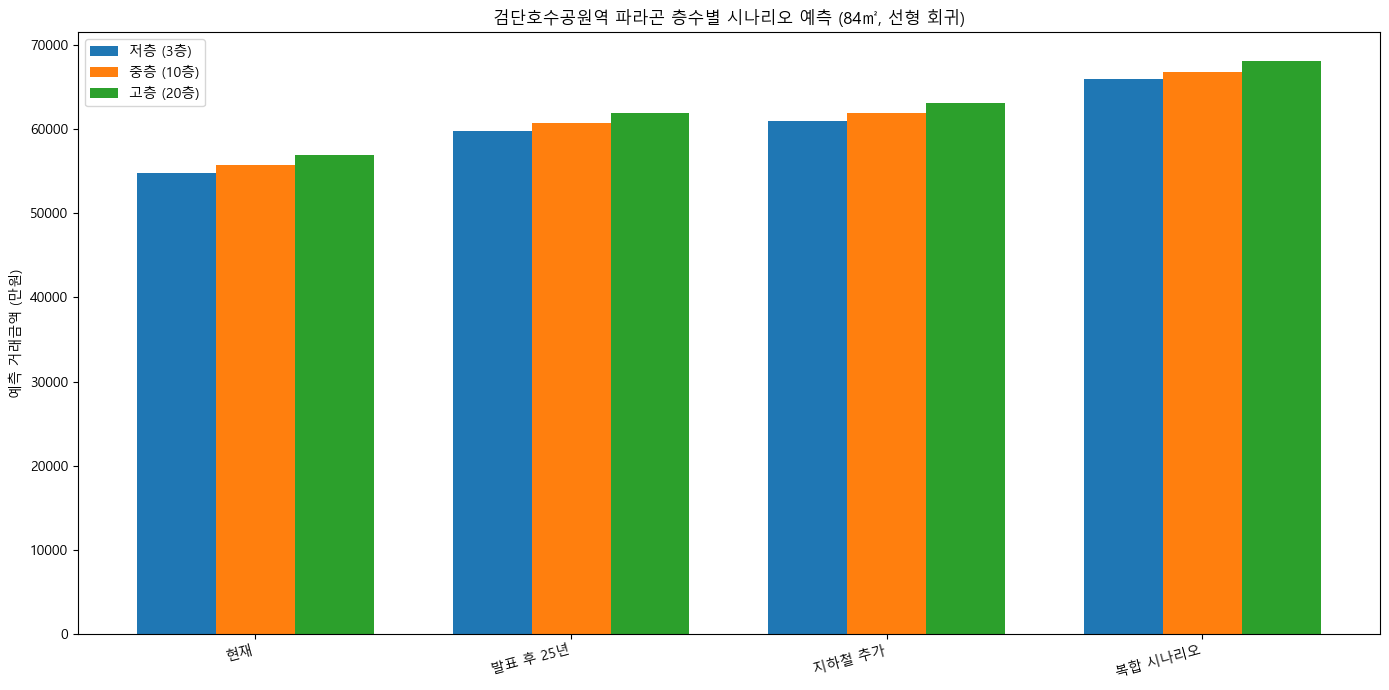

In [14]:
# ── 층수별 그래프 ──
x = np.arange(len(시나리오_목록))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 7))
for i, (층이름, 값들) in enumerate(층수_결과.items()):
    ax.bar(x + i * width, 값들, width, label=층이름)
ax.set_xticks(x + width)
ax.set_xticklabels(시나리오_목록.keys(), rotation=15, ha='right')
ax.set_ylabel('예측 거래금액 (만원)')
ax.set_title('검단호수공원역 파라곤 층수별 시나리오 예측 (84㎡, 선형 회귀)')
ax.legend()
plt.tight_layout()
plt.show()